# GiBUU FSI (Final State Interaction) Model Training

This notebook trains the `GiBUUInteractionModel` (Encoder-Decoder Transformer) for predicting final state particles from initial state particles.

**Workflow:**
1. Extract first step -> last step pairs from H5 files (or load from existing NPZ files)
2. Save pairs to NPZ format (flattened, no padding waste)
3. Prepare data for training (call `prepare_fsi_data`)
4. Configure model and training parameters
5. Train model with PyTorch Lightning
6. Test trained model

**Model Architecture:**
- Encoder-Decoder Transformer architecture (same as interaction model)
- Encoder processes first time step (t_first)
- Decoder generates last time step (t_last) with teacher forcing
- Bidirectional attention (particles in same timestep can attend to each other)
- Predicts particle types and features
- Option to mask position features (x, y, z) if not useful for FSI task

**Output:**
- Trained model saved in `lightning_logs/`
- Checkpoints for resuming training or inference


## Step 1: Imports


In [7]:
# Enable auto-reload of modules
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl
import numpy as np
import glob
from pathlib import Path
from typing import List, Tuple, Dict

# Import from gibuu_transformer package
from gibuu_transformer import (
    GiBUUInteractionModel,
    GiBUUInteractionLightning,
    gibuu_interaction_loss,
    prepare_fsi_data,
    load_pairs_from_npz,
    FEATS_MEAN,
    FEATS_SIGMA,
    EOS_STEP_TOKEN,
    PAD_TOKEN,
    START_TOKEN,
    list_checkpoints,
    find_checkpoint
)

print(f"✓ Imports successful!")
print(f"  PyTorch version: {torch.__version__}")
print(f"  Lightning version: {pl.__version__}")
print(f"  Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"\nFeature normalization constants loaded:")
print(f"  FEATS_MEAN: {FEATS_MEAN}")
print(f"  FEATS_SIGMA: {FEATS_SIGMA}")


✓ Imports successful!
  PyTorch version: 2.8.0+cu128
  Lightning version: 2.5.2
  Device: cuda

Feature normalization constants loaded:
  FEATS_MEAN: [0.0, 0.0, 6.13, 0.42, 0.0, 0.0, 0.5]
  FEATS_SIGMA: [5.89, 5.89, 9.33, 0.975, 0.304, 0.304, 1.123]


## Step 2: Extract and Save FSI Pairs (or Load from NPZ)

Extract first step -> last step pairs from event sequences and save to NPZ, or load existing NPZ files.


In [8]:
# Configuration
H5_BASE_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata"
NPZ_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata/processed_data"
JOB_ID = 990
MAX_PAIRS = None  # Set to a number for quick testing, None to load all
MAX_EVENTS = None  # Set to a number to limit events during extraction, None for all

# Check if FSI NPZ file already exists
fsi_file = Path(NPZ_PATH) / "npz_fsi" / f"pairs_fsi_{JOB_ID:06d}.npz"
fsi_dir = Path(NPZ_PATH) / "npz_fsi"
fsi_dir.mkdir(parents=True, exist_ok=True)

if fsi_file.exists():
    # Load existing FSI pairs from NPZ
    print(f"Loading Job {JOB_ID:06d} from existing NPZ file...")
    print(f"  FSI file: {fsi_file.name} ✓")
    
    fsi_files = [str(fsi_file)]
    fsi_pairs = load_pairs_from_npz(fsi_files, max_pairs=MAX_PAIRS, random_subset=True)
    
    print(f"\n✓ Data loaded: {len(fsi_pairs)} FSI pairs (first step -> last step)")
    if MAX_PAIRS is not None:
        print(f"  (Limited to {MAX_PAIRS} pairs for quick testing)")
else:
    # Extract FSI pairs from H5 files and save to NPZ
    print(f"Extracting FSI pairs for Job {JOB_ID:06d}...")
    
    # Import additional functions needed for extraction
    from gibuu_transformer import extract_particle_sequences, extract_first_last_pairs
    
    # Load H5 file
    h5_file = Path(H5_BASE_PATH) / f"GiBUU_FSI_{JOB_ID:06d}.h5"
    GROUP_KEY = "perturbative"
    
    print(f"  H5 file: {h5_file.name} {'✓' if h5_file.exists() else '✗'}")
    
    if not h5_file.exists():
        raise FileNotFoundError(f"H5 file not found: {h5_file}")
    
    # Extract event sequences
    print(f"\n  Extracting event sequences...")
    all_sequences = extract_particle_sequences(str(h5_file), gr_key=GROUP_KEY)
    
    # Limit number of events if specified
    if MAX_EVENTS is not None and MAX_EVENTS < len(all_sequences):
        print(f"  Limiting to {MAX_EVENTS} events (from {len(all_sequences)} total)")
        all_sequences = all_sequences[:MAX_EVENTS]
    
    print(f"  ✓ Loaded {len(all_sequences)} event sequences")
    
    # Extract first->last step pairs (no truncation - padding happens in collate function)
    print(f"\n  Extracting first->last step pairs...")
    fsi_pairs = extract_first_last_pairs(all_sequences)
    
    print(f"  ✓ Extracted {len(fsi_pairs)} FSI pairs")
    
    if len(fsi_pairs) > 0:
        input_sizes = [len(inp) for inp, _ in fsi_pairs]
        output_sizes = [len(out) for _, out in fsi_pairs]
        print(f"    Input (first step) - min: {min(input_sizes)}, max: {max(input_sizes)}, avg: {np.mean(input_sizes):.1f}")
        print(f"    Output (last step) - min: {min(output_sizes)}, max: {max(output_sizes)}, avg: {np.mean(output_sizes):.1f}")
    
    # Save to NPZ (flattened format - no padding waste!)
    print(f"\n  Saving FSI pairs to NPZ...")
    
    # Helper function to convert pairs to NPZ (flattened format)
    def pairs_to_npz(pairs_list):
        """
        Store pairs in flattened format to avoid padding waste.
        
        Format:
        - input_particles: Flattened array of all input particles (N_total_input, 11)
        - output_particles: Flattened array of all output particles (N_total_output, 11)
        - input_lengths: Number of particles in each input sequence (n_pairs,)
        - output_lengths: Number of particles in each output sequence (n_pairs,)
        """
        if len(pairs_list) == 0:
            return {}
        
        n_pairs = len(pairs_list)
        
        # Flatten all particles (no padding!)
        all_input_particles = []
        all_output_particles = []
        input_lengths = []
        output_lengths = []
        
        for inp, out in pairs_list:
            all_input_particles.extend(inp)
            all_output_particles.extend(out)
            input_lengths.append(len(inp))
            output_lengths.append(len(out))
        
        # Convert to arrays
        input_particles = np.array(all_input_particles, dtype=np.float32)  # (N_total_input, 11)
        output_particles = np.array(all_output_particles, dtype=np.float32)  # (N_total_output, 11)
        input_lengths = np.array(input_lengths, dtype=np.int32)  # (n_pairs,)
        output_lengths = np.array(output_lengths, dtype=np.int32)  # (n_pairs,)
        
        return {
            'input_particles': input_particles,
            'output_particles': output_particles,
            'input_lengths': input_lengths,
            'output_lengths': output_lengths
        }
    
    # Save to NPZ
    if len(fsi_pairs) > 0:
        arrays = pairs_to_npz(fsi_pairs)
        np.savez_compressed(fsi_file, **arrays)
        size_mb = fsi_file.stat().st_size / 1e6
        print(f"  ✓ Saved: {fsi_file.name} ({size_mb:.1f} MB, {len(fsi_pairs)} pairs)")
        print(f"    Format: Flattened (no padding waste!)")
        print(f"    - input_particles: (N_total_input, 11)")
        print(f"    - output_particles: (N_total_output, 11)")
        print(f"    - input_lengths, output_lengths: (n_pairs,)")
    else:
        print(f"  ⚠ No FSI pairs to save")
    
    # Limit pairs if specified
    if MAX_PAIRS is not None and MAX_PAIRS < len(fsi_pairs):
        print(f"\n  Limiting to {MAX_PAIRS} pairs for quick testing...")
        import random
        random.seed(42)
        fsi_pairs = random.sample(fsi_pairs, MAX_PAIRS)
        print(f"  ✓ Using {len(fsi_pairs)} pairs")

print(f"\n✓ Ready: {len(fsi_pairs)} FSI pairs (first step -> last step)")


Loading Job 000990 from existing NPZ file...
  FSI file: pairs_fsi_000990.npz ✓

✓ Data loaded: 18478 FSI pairs (first step -> last step)

✓ Ready: 18478 FSI pairs (first step -> last step)


## Step 3: Prepare Data for Training

Convert pairs to format expected by the interaction model (encoder-decoder).
Option to mask position features (x, y, z) if they are not useful for FSI task.


In [9]:
# Configuration: Mask position features if desired
MASK_POSITION_FEATURES = True  # Set to True to mask x, y, z features (set to zero)

# Prepare FSI data
fsi_data = prepare_fsi_data(
    fsi_pairs,
    stats_path=None,  # Uses constants from constants.py
    mask_position_features=MASK_POSITION_FEATURES
)

print("✓ Data prepared for training:")
print(f"  Total pairs: {len(fsi_data['input_encoded_ids'])}")

# Show example
idx = 0
print(f"\nExample pair {idx}:")
print(f"  Input IDs: {fsi_data['input_encoded_ids'][idx][:5]}... ({len(fsi_data['input_encoded_ids'][idx])} total)")
print(f"  Output IDs: {fsi_data['output_encoded_ids'][idx][:5]}... ({len(fsi_data['output_encoded_ids'][idx])} total)")
if MASK_POSITION_FEATURES:
    print(f"  Note: Position features (x, y, z) are masked (set to zero)")


Preparing 18478 FSI pairs (first step -> last step) for training...
  Note: Position features (x, y, z) will be masked (set to zero)
✓ Prepared 18478 FSI pairs
  Features: [x, y, z, KE, Px, Py, Pz] where KE = E - m
  Normalization: (feature - FEATS_MEAN) / FEATS_SIGMA
  Position features (x, y, z) masked (set to zero)
✓ Data prepared for training:
  Total pairs: 18478

Example pair 0:
  Input IDs: [1153, 1024]... (2 total)
  Output IDs: [2048, 1153, 1024]... (3 total)
  Note: Position features (x, y, z) are masked (set to zero)


## Step 4: Create Dataset and DataLoader


In [10]:
class TimeStepPairDataset(Dataset):
    """
    Dataset for time step pairs with variable-length sequences.
    """
    def __init__(self, pair_data):
        self.input_encoded_ids = pair_data['input_encoded_ids']
        self.input_particle_feats = pair_data['input_particle_feats']
        self.output_encoded_ids = pair_data['output_encoded_ids']
        self.output_particle_feats = pair_data['output_particle_feats']
    
    def __len__(self):
        return len(self.input_encoded_ids)
    
    def __getitem__(self, idx):
        return {
            'input_encoded_ids': self.input_encoded_ids[idx],
            'input_particle_feats': self.input_particle_feats[idx],
            'output_encoded_ids': self.output_encoded_ids[idx],
            'output_particle_feats': self.output_particle_feats[idx]
        }

def collate_timestep_pairs(batch):
    """
    Custom collate function for variable-length time step pairs.
    Pads each batch to the maximum length within that batch.
    """
    # Extract all sequences from batch
    input_ids_list = [item['input_encoded_ids'] for item in batch]
    input_feats_list = [item['input_particle_feats'] for item in batch]
    output_ids_list = [item['output_encoded_ids'] for item in batch]
    output_feats_list = [item['output_particle_feats'] for item in batch]
    
    # Find max lengths in this batch
    max_input_len = max(len(ids) for ids in input_ids_list)
    max_output_len = max(len(ids) for ids in output_ids_list)
    max_seq_len = max(max_input_len, max_output_len)
    
    batch_size = len(batch)
    
    # Pad input sequences
    input_encoded_ids_padded = []
    input_particle_feats_padded = []
    input_padding_mask_list = []
    
    for ids, feats in zip(input_ids_list, input_feats_list):
        pad_len = max_seq_len - len(ids)
        if pad_len > 0:
            ids_padded = ids + [PAD_TOKEN] * pad_len
            feats_padded = feats + [[0.0] * 7] * pad_len
            padding_mask = [False] * len(ids) + [True] * pad_len
        else:
            ids_padded = ids
            feats_padded = feats
            padding_mask = [False] * len(ids)
        
        input_encoded_ids_padded.append(ids_padded)
        input_particle_feats_padded.append(feats_padded)
        input_padding_mask_list.append(padding_mask)
    
    # Pad output sequences
    output_encoded_ids_padded = []
    output_particle_feats_padded = []
    output_padding_mask_list = []
    
    for ids, feats in zip(output_ids_list, output_feats_list):
        pad_len = max_seq_len - len(ids)
        if pad_len > 0:
            ids_padded = ids + [PAD_TOKEN] * pad_len
            feats_padded = feats + [[0.0] * 7] * pad_len
            padding_mask = [False] * len(ids) + [True] * pad_len
        else:
            ids_padded = ids
            feats_padded = feats
            padding_mask = [False] * len(ids)
        
        output_encoded_ids_padded.append(ids_padded)
        output_particle_feats_padded.append(feats_padded)
        output_padding_mask_list.append(padding_mask)
    
    # Convert to tensors
    return {
        'input_encoded_ids': torch.tensor(input_encoded_ids_padded, dtype=torch.long),
        'input_particle_feats': torch.tensor(input_particle_feats_padded, dtype=torch.float32),
        'input_padding_mask': torch.tensor(input_padding_mask_list, dtype=torch.bool),
        'output_encoded_ids': torch.tensor(output_encoded_ids_padded, dtype=torch.long),
        'output_particle_feats': torch.tensor(output_particle_feats_padded, dtype=torch.float32),
        'output_padding_mask': torch.tensor(output_padding_mask_list, dtype=torch.bool)
    }

# Create dataset
dataset = TimeStepPairDataset(fsi_data)

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"✓ Datasets created:")
print(f"  Train: {len(train_dataset)} pairs")
print(f"  Val: {len(val_dataset)} pairs")


✓ Datasets created:
  Train: 14782 pairs
  Val: 3696 pairs


In [13]:
# Load config from file
import json
with open('config.json', 'r') as f:
    cfg = json.load(f)

# Override settings for FSI model
cfg['type_loss_weight'] = 1.0
cfg['feat_loss_weight'] = 10 #1.0
cfg['lr'] = 1e-4
cfg['weight_decay'] = 1e-5

# Training hyperparameters
BATCH_SIZE = 32
MAX_EPOCHS = 1000
LOG_EVERY_N_STEPS = 100
EARLY_STOP_PATIENCE = 10  # Patience in epochs for EarlyStopping
EXPERIMENT_NAME = "gibuu_fsi"

# Resume training configuration
RESUME_TRAINING = True
CHECKPOINT_PATH = None
CHECKPOINT_NAME = "last.ckpt"

# Update config with trainer settings
cfg['trainer'] = {
    'batch_size': BATCH_SIZE,
    'max_epochs': MAX_EPOCHS,
    'log_every_n_steps': LOG_EVERY_N_STEPS
}

print("✓ Configuration set:")
print(f"  Model: GiBUUInteractionModel (Encoder-Decoder Transformer)")
print(f"  Learning rate: {cfg['lr']}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {MAX_EPOCHS}")
print(f"  Resume training: {RESUME_TRAINING}")
if MASK_POSITION_FEATURES:
    print(f"  Position features masked: Yes (x, y, z set to zero)")
else:
    print(f"  Position features masked: No")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_timestep_pairs,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_timestep_pairs,
    num_workers=4,
    pin_memory=True
)

print(f"\n✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

# Create model (with resume support)
if RESUME_TRAINING:
    CHECKPOINT_PATH = find_checkpoint(
        experiment_name=EXPERIMENT_NAME,
        checkpoint_path=CHECKPOINT_PATH,
        checkpoint_name=CHECKPOINT_NAME
    )
    
    if CHECKPOINT_PATH is not None:
        print(f"✓ Resuming from checkpoint: {CHECKPOINT_PATH}")
        model = GiBUUInteractionLightning.load_from_checkpoint(CHECKPOINT_PATH, cfg=cfg)
    else:
        print("⚠ No checkpoint found, starting new training")
        RESUME_TRAINING = False
        model = GiBUUInteractionLightning(cfg)
else:
    print("✓ Starting new training")
    model = GiBUUInteractionLightning(cfg)

# Create trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=LOG_EVERY_N_STEPS,
    
    # Checkpointing
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=f'lightning_logs/{EXPERIMENT_NAME}/checkpoints',
            filename='model-{epoch:02d}-{val_loss:.4f}',
            monitor='val_loss',
            mode='min',
            save_top_k=3,
            save_last=True
        ),
        # Note: EarlyStopping disabled when resuming via ckpt_path to avoid state issues
        # You can re-enable with a fresh Trainer if you don't need continuous epoch numbering.
    ],
    
    # Logging
    logger=pl.loggers.CSVLogger(
        save_dir='lightning_logs',
        name=EXPERIMENT_NAME
    )
)

print(f"\n✓ Trainer created")
print(f"  Logs will be saved to: lightning_logs/{EXPERIMENT_NAME}/")
print(f"  Checkpoints will be saved to: lightning_logs/{EXPERIMENT_NAME}/checkpoints/")


✓ Configuration set:
  Model: GiBUUInteractionModel (Encoder-Decoder Transformer)
  Learning rate: 0.0001
  Batch size: 32
  Max epochs: 1000
  Resume training: True
  Position features masked: Yes (x, y, z set to zero)

✓ DataLoaders created:
  Train batches: 462
  Val batches: 116
✓ Found checkpoint: lightning_logs/gibuu_fsi/checkpoints/last.ckpt
✓ Resuming from checkpoint: lightning_logs/gibuu_fsi/checkpoints/last.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



✓ Trainer created
  Logs will be saved to: lightning_logs/gibuu_fsi/
  Checkpoints will be saved to: lightning_logs/gibuu_fsi/checkpoints/


In [ ]:
# Train!
if RESUME_TRAINING and CHECKPOINT_PATH is not None:
    print(f"\nResuming training from checkpoint (continuous epochs)...\n")
    trainer.fit(model, train_loader, val_loader, ckpt_path=CHECKPOINT_PATH)
else:
    print("Starting training from scratch...\n")
    trainer.fit(model, train_loader, val_loader)

print("\n✓ Training complete!")
print(f"  Best model checkpoint: {trainer.checkpoint_callback.best_model_path}")
print(f"  Last checkpoint: {trainer.checkpoint_callback.last_model_path}")

Loading metrics from: lightning_logs/gibuu_fsi_1203/version_0/metrics.csv
Columns: ['epoch', 'step', 'train_feat_loss', 'train_loss', 'train_type_loss', 'val_feat_loss', 'val_loss', 'val_type_loss']
✓ Loss curves plotted for interaction model

FINAL LOSS VALUES (Epoch 999):
  val_loss                      : 0.678917
  val_type_loss                 : 0.460363
  val_feat_loss                 : 0.021855


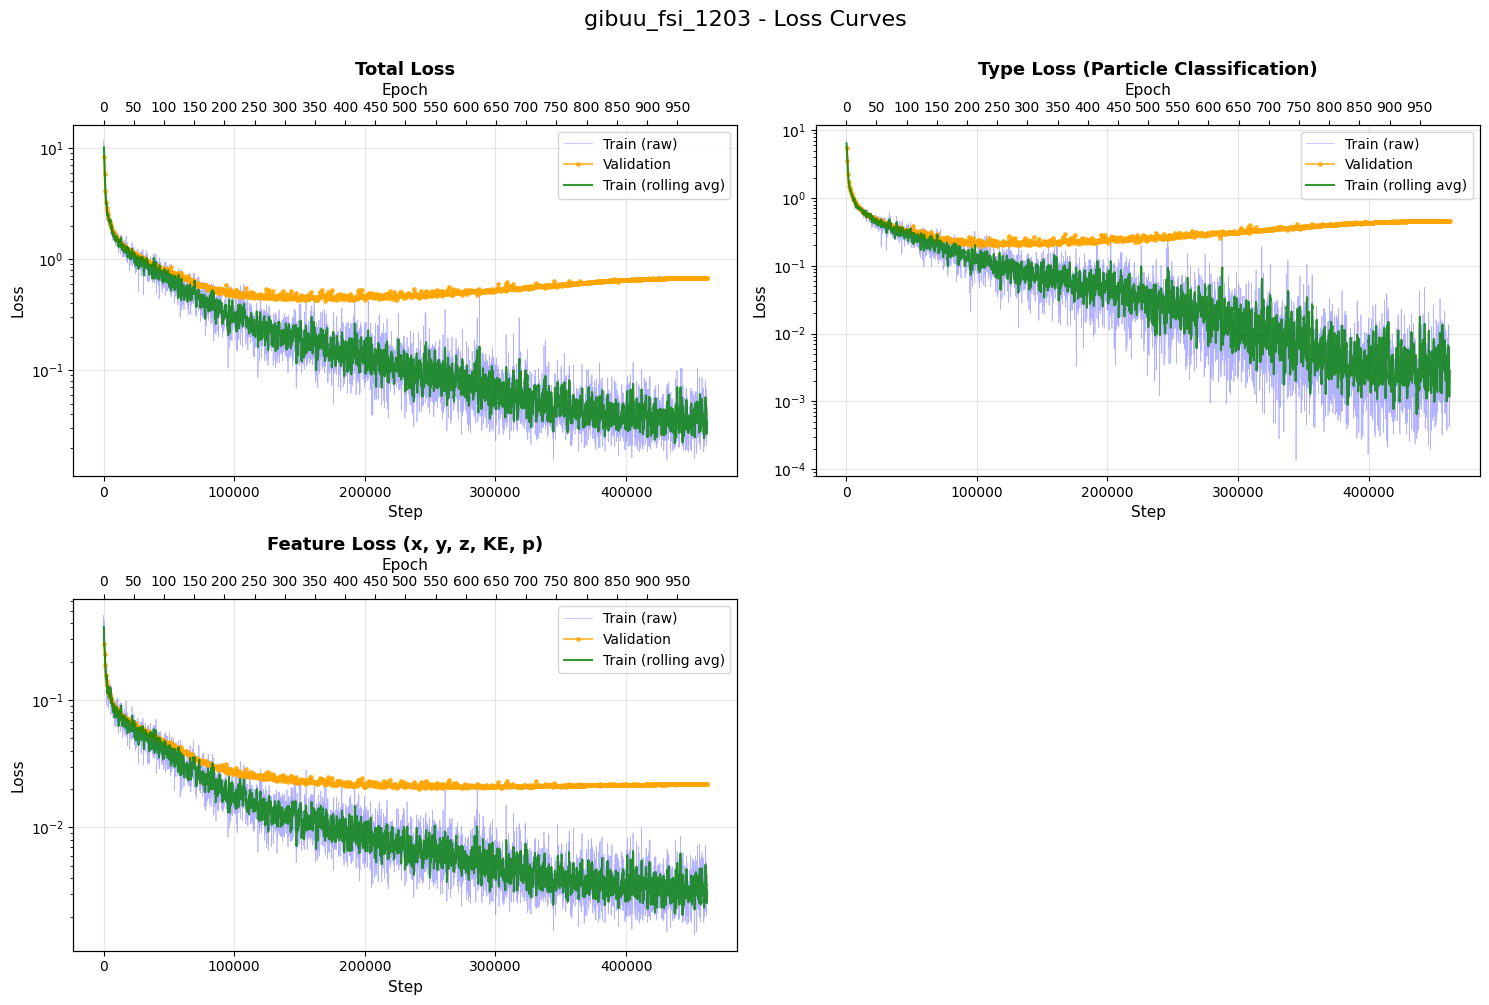

In [3]:
### Plot Loss Curves
from gibuu_transformer import plot_loss_curves
import matplotlib.pyplot as plt
import pandas as pd

EXPERIMENT_NAME = "gibuu_fsi_1203"
COMBINE_CSV = False
if COMBINE_CSV:
    csv_idx_list = [0, 11] # modify the list
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"
    dfs = [pd.read_csv(f'lightning_logs/{EXPERIMENT_NAME}/version_{i}/metrics.csv') for i in csv_idx_list]
    combined = pd.concat(dfs, ignore_index=True)
    combined.to_csv(csv_path, index=False)
else:
    csv_idx = 0 # modify the index
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/version_{csv_idx}/metrics.csv"

# Option 2: Plot from combined CSV (if you've combined multiple versions)
# csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"

fig, axes = plot_loss_curves(
    csv_path=csv_path,
    mode='interaction',
    figsize=(15, 10),
    title=f'{EXPERIMENT_NAME} - Loss Curves',
    logy=True
)

if fig is not None:
    plt.show()

---

## Test

Load trained model and test on sample data.


In [11]:
### Load Best Checkpoint

#checkpoint_path = trainer.checkpoint_callback.best_model_path
checkpoint_path = "lightning_logs/gibuu_fsi/checkpoints/last.ckpt"

model_loaded = GiBUUInteractionLightning.load_from_checkpoint(checkpoint_path)
model_loaded.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_loaded.to(device)

print(f"✓ Model loaded from: {checkpoint_path}")

✓ Model loaded from: lightning_logs/gibuu_fsi/checkpoints/last.ckpt


In [23]:
### Load Test Sample

# Configuration for test sample
TEST_SAMPLE_SIZE = 10000  # Number of pairs to load for testing

# Option 1: Use a subset of the training sample (COMMENTED OUT)
'''import random
random.seed(42)
test_indices = random.sample(range(len(train_dataset)), min(TEST_SAMPLE_SIZE, len(train_dataset)))
test_subset = torch.utils.data.Subset(train_dataset, test_indices)
test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_timestep_pairs,
    num_workers=0,  # Set to 0 for testing
    pin_memory=False
)
print(f"✓ Test sample loaded from training data: {len(test_subset)} pairs")'''

# Option 2: Load test sample from NPZ file with TEST_JOB_ID
TEST_JOB_ID = 1000
test_file = Path(NPZ_PATH) / "npz_fsi" / f"pairs_fsi_{TEST_JOB_ID:06d}.npz"
test_files = [str(test_file)] if test_file.exists() else []

if not test_files:
    print(f"⚠ Test file not found: {test_file}")
    print("  Falling back to validation loader...")
    test_loader = val_loader
else:
    print(f"Loading test sample from Job {TEST_JOB_ID:06d}...")
    print(f"  Test file: {test_file.name} {'✓' if test_file.exists() else '✗'}")
    
    # Load test pairs
    test_pairs = load_pairs_from_npz(test_files, max_pairs=TEST_SAMPLE_SIZE, random_subset=True)
    
    if len(test_pairs) == 0:
        print("⚠ No test pairs loaded, falling back to validation loader...")
        test_loader = val_loader
    else:
        print(f"✓ Test pairs loaded: {len(test_pairs)} pairs")
        
        # Prepare test data
        test_data = prepare_fsi_data(
            test_pairs,
            stats_path=None,  # Uses constants from constants.py
            mask_position_features=MASK_POSITION_FEATURES  # Must match training data preparation
        )
        
        # Create test dataset and loader
        test_dataset = TimeStepPairDataset(test_data)
        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=collate_timestep_pairs,
            num_workers=0,  # Set to 0 for testing
            pin_memory=False
        )
        
        print(f"✓ Test dataset created: {len(test_dataset)} pairs")
        print(f"  Test batches: {len(test_loader)}")


Loading test sample from Job 001000...
  Test file: pairs_fsi_001000.npz ✓
✓ Test pairs loaded: 10000 pairs
Preparing 10000 FSI pairs (first step -> last step) for training...
  Note: Position features (x, y, z) will be masked (set to zero)
✓ Prepared 10000 FSI pairs
  Features: [x, y, z, KE, Px, Py, Pz] where KE = E - m
  Normalization: (feature - FEATS_MEAN) / FEATS_SIGMA
  Position features (x, y, z) masked (set to zero)
✓ Test dataset created: 10000 pairs
  Test batches: 313


In [24]:
### Example Events from Test Sample
from gibuu_transformer.data_processing import decode_id

# Get a batch from test loader
model_loaded.eval()
example_batch = next(iter(test_loader))
example_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in example_batch.items()}

# Make predictions
with torch.no_grad():
    output = model_loaded(
        example_batch['input_encoded_ids'],
        example_batch['input_particle_feats'],
        example_batch['input_padding_mask'],
        example_batch['output_encoded_ids'],
        example_batch['output_particle_feats'],
        example_batch['output_padding_mask']
    )

# Helper function to decode particle ID to readable format
def format_particle_id(encoded_id):
    """Format encoded particle ID to readable string."""
    if encoded_id == PAD_TOKEN:
        return "PAD"
    elif encoded_id == EOS_STEP_TOKEN:
        return "EOS"
    elif encoded_id == START_TOKEN:
        return "START"
    else:
        try:
            gibuu_id, charge, is_real = decode_id(int(encoded_id))
            charge_str = f"+{charge}" if charge > 0 else str(charge) if charge < 0 else "0"
            return f"ID={gibuu_id},Q={charge_str}"
        except:
            return f"Unknown({encoded_id})"

# Helper function to format features
def format_features(feats_norm, feats_mean, feats_sigma):
    """Denormalize and format features."""
    feats_denorm = feats_norm * feats_sigma + feats_mean
    return {
        'x': feats_denorm[0].item(),
        'y': feats_denorm[1].item(),
        'z': feats_denorm[2].item(),
        'KE': feats_denorm[3].item(),
        'Px': feats_denorm[4].item(),
        'Py': feats_denorm[5].item(),
        'Pz': feats_denorm[6].item()
    }

# Prepare normalization tensors
feats_mean = torch.tensor(FEATS_MEAN, dtype=torch.float32)
feats_sigma = torch.tensor(FEATS_SIGMA, dtype=torch.float32)

# Get decoder input and targets (shifted)
decoder_input_ids = example_batch['output_encoded_ids']  # (batch, seq_len)
decoder_input_feats = example_batch['output_particle_feats']  # (batch, seq_len, 7)
target_types = decoder_input_ids[:, 1:]  # (batch, seq_len-1)
target_feats = decoder_input_feats[:, 1:]  # (batch, seq_len-1, 7)
target_padding_mask = example_batch['output_padding_mask'][:, 1:]  # (batch, seq_len-1)

# Align predictions
target_len = target_types.size(1)
predicted_types = output['particle_types'][:, :target_len].argmax(dim=-1)  # (batch, seq_len-1)
predicted_feats = output['particle_feats'][:, :target_len]  # (batch, seq_len-1, 7)

# Get input
input_ids = example_batch['input_encoded_ids']  # (batch, input_seq_len)
input_feats = example_batch['input_particle_feats']  # (batch, input_seq_len, 7)
input_padding_mask = example_batch['input_padding_mask']  # (batch, input_seq_len)

# Select 5 examples (or fewer if batch is smaller)
num_examples = min(3, predicted_types.size(0))

print(f"{'='*100}")
print(f"EXAMPLE PREDICTIONS (showing {num_examples} examples from test sample)")
print(f"{'='*100}")

for iex in range(num_examples):
    print(f"\n{'='*100}")
    print(f"EXAMPLE {iex + 1}")
    print(f"{'='*100}")
    
    # Get input particles (excluding padding)
    input_mask = ~input_padding_mask[iex]
    input_ids_valid = input_ids[iex][input_mask].cpu().numpy()
    input_feats_valid = input_feats[iex][input_mask].cpu()
    
    # Get target and predicted particles (excluding padding)
    target_mask = ~target_padding_mask[iex]
    target_ids_valid = target_types[iex][target_mask].cpu().numpy()
    target_feats_valid = target_feats[iex][target_mask].cpu()
    predicted_ids_valid = predicted_types[iex][target_mask].cpu().numpy()
    predicted_feats_valid = predicted_feats[iex][target_mask].cpu()
    
    # Display INPUT
    print(f"\n📥 INPUT (t1) - {len(input_ids_valid)} particles:")
    print(f"{'Index':<8} {'Type':<25} {'x (fm)':<12} {'y (fm)':<12} {'z (fm)':<12} {'KE (GeV)':<12} {'Px (GeV)':<12} {'Py (GeV)':<12} {'Pz (GeV)':<12}")
    print(f"{'-'*100}")
    for ip, (pid, pfeat) in enumerate(zip(input_ids_valid, input_feats_valid)):
        ptype_str = format_particle_id(pid)
        pfeat_dict = format_features(pfeat, feats_mean, feats_sigma)
        print(f"{ip:<8} {ptype_str:<25} {pfeat_dict['x']:<12.4f} {pfeat_dict['y']:<12.4f} {pfeat_dict['z']:<12.4f} "
              f"{pfeat_dict['KE']:<12.6f} {pfeat_dict['Px']:<12.6f} {pfeat_dict['Py']:<12.6f} {pfeat_dict['Pz']:<12.6f}")
    
    # Display TARGET OUTPUT
    print(f"\n🎯 TARGET OUTPUT (t2) - {len(target_ids_valid)} particles:")
    print(f"{'Index':<8} {'Type':<25} {'x (fm)':<12} {'y (fm)':<12} {'z (fm)':<12} {'KE (GeV)':<12} {'Px (GeV)':<12} {'Py (GeV)':<12} {'Pz (GeV)':<12}")
    print(f"{'-'*100}")
    for ip, (pid, pfeat) in enumerate(zip(target_ids_valid, target_feats_valid)):
        ptype_str = format_particle_id(pid)
        pfeat_dict = format_features(pfeat, feats_mean, feats_sigma)
        print(f"{ip:<8} {ptype_str:<25} {pfeat_dict['x']:<12.4f} {pfeat_dict['y']:<12.4f} {pfeat_dict['z']:<12.4f} "
              f"{pfeat_dict['KE']:<12.6f} {pfeat_dict['Px']:<12.6f} {pfeat_dict['Py']:<12.6f} {pfeat_dict['Pz']:<12.6f}")
    
    # Display PREDICTED OUTPUT
    print(f"\n🤖 PREDICTED OUTPUT (t2) - {len(predicted_ids_valid)} particles:")
    print(f"{'Index':<8} {'Type':<25} {'x (fm)':<12} {'y (fm)':<12} {'z (fm)':<12} {'KE (GeV)':<12} {'Px (GeV)':<12} {'Py (GeV)':<12} {'Pz (GeV)':<12} {'Match':<8}")
    print(f"{'-'*100}")
    correct_count = 0
    for ip, (pred_pid, pred_pfeat, targ_pid, targ_pfeat) in enumerate(zip(
        predicted_ids_valid, predicted_feats_valid, target_ids_valid, target_feats_valid
    )):
        pred_ptype_str = format_particle_id(pred_pid)
        pred_pfeat_dict = format_features(pred_pfeat, feats_mean, feats_sigma)
        match = "✓" if pred_pid == targ_pid else "✗"
        if pred_pid == targ_pid:
            correct_count += 1
        print(f"{ip:<8} {pred_ptype_str:<25} {pred_pfeat_dict['x']:<12.4f} {pred_pfeat_dict['y']:<12.4f} {pred_pfeat_dict['z']:<12.4f} "
              f"{pred_pfeat_dict['KE']:<12.6f} {pred_pfeat_dict['Px']:<12.6f} {pred_pfeat_dict['Py']:<12.6f} {pred_pfeat_dict['Pz']:<12.6f} {match:<8}")
    
    # Summary for this example
    type_accuracy = correct_count / len(target_ids_valid) if len(target_ids_valid) > 0 else 0.0
    print(f"\n📊 Summary for Example {iex + 1}:")
    print(f"  Type Accuracy: {type_accuracy:.2%} ({correct_count}/{len(target_ids_valid)})")
    
    # Calculate feature errors for this example
    pred_feats_denorm = predicted_feats_valid * feats_sigma.unsqueeze(0) + feats_mean.unsqueeze(0)
    targ_feats_denorm = target_feats_valid * feats_sigma.unsqueeze(0) + feats_mean.unsqueeze(0)
    
    # Exclude EOS from feature errors
    non_eos_mask = torch.tensor([pid != EOS_STEP_TOKEN for pid in target_ids_valid], dtype=torch.bool)
    if non_eos_mask.sum() > 0:
        pred_feats_particles = pred_feats_denorm[non_eos_mask]
        targ_feats_particles = targ_feats_denorm[non_eos_mask]
        
        feature_rmse = torch.sqrt(torch.mean((pred_feats_particles - targ_feats_particles) ** 2, dim=0))
        print(f"  Feature RMSE (excluding EOS):")
        print(f"    x: {feature_rmse[0]:.4f} fm, y: {feature_rmse[1]:.4f} fm, z: {feature_rmse[2]:.4f} fm")
        print(f"    KE: {feature_rmse[3]:.6f} GeV, Px: {feature_rmse[4]:.6f} GeV, Py: {feature_rmse[5]:.6f} GeV, Pz: {feature_rmse[6]:.6f} GeV")

print(f"\n{'='*100}")
print("✓ Examples displayed")


EXAMPLE PREDICTIONS (showing 3 examples from test sample)

EXAMPLE 1

📥 INPUT (t1) - 5 particles:
Index    Type                      x (fm)       y (fm)       z (fm)       KE (GeV)     Px (GeV)     Py (GeV)     Pz (GeV)    
----------------------------------------------------------------------------------------------------
0        ID=103,Q=+1               0.0000       0.0000       0.0000       2.636546     -0.468530    0.014138     3.595674    
1        ID=101,Q=-1               0.0000       0.0000       0.0000       2.611274     -0.305049    0.104601     2.726805    
2        ID=1,Q=+1                 0.0000       0.0000       0.0000       0.758632     -0.181479    0.044576     1.401839    
3        ID=103,Q=+1               0.0000       0.0000       0.0000       0.272178     0.115706     -0.125802    0.743396    
4        EOS                       0.0000       0.0000       6.1300       0.420000     0.000000     0.000000     0.500000    

🎯 TARGET OUTPUT (t2) - 14 particles:
Index  

/tmp/ipykernel_114281/2684192725.py:142: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  non_eos_mask = torch.tensor([pid != EOS_STEP_TOKEN for pid in target_ids_valid], dtype=torch.bool)


### Evaluation Metrics

Calculate overall class accuracy and feature errors on the test sample.


In [25]:
# Evaluate on entire test set
model_loaded.eval()
all_predicted_types = []
all_true_types = []
all_predicted_feats = []
all_true_feats = []
all_masks = []  # True for valid tokens (not PAD, but include EOS)

feature_names = ['x', 'y', 'z', 'KE', 'Px', 'Py', 'Pz']

print("Evaluating on test set...")
with torch.no_grad():
    for batch in test_loader:
        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        
        # Predict
        output = model_loaded(
            batch['input_encoded_ids'],
            batch['input_particle_feats'],
            batch['input_padding_mask'],
            batch['output_encoded_ids'],
            batch['output_particle_feats'],
            batch['output_padding_mask']
        )
        
        # Decoder input: [START, P1, P2, ..., PN, EOS, PAD, ...]
        decoder_input_ids = batch['output_encoded_ids']  # (batch, seq_len)
        decoder_input_feats = batch['output_particle_feats']  # (batch, seq_len, 7)
        output_padding_mask = batch['output_padding_mask']  # (batch, seq_len)
        
        # Compute targets by shifting decoder input (remove START token)
        # Targets: [P1, P2, ..., PN, EOS, PAD, ...] = decoder_input[:, 1:]
        target_types = decoder_input_ids[:, 1:]  # (batch, seq_len-1)
        target_feats = decoder_input_feats[:, 1:]  # (batch, seq_len-1, 7)
        target_padding_mask = output_padding_mask[:, 1:]  # (batch, seq_len-1)
        valid_mask = ~target_padding_mask  # (batch, seq_len-1), True = valid (including EOS)
        
        # Align predictions with targets
        # particle_types[0] (pred after START) → target[0] (P1)
        # particle_types[1] (pred after P1) → target[1] (P2)
        # particle_types[N] (pred after PN) → target[N] (EOS)
        target_len = target_types.size(1)
        predicted_types = output['particle_types'][:, :target_len].argmax(dim=-1)  # (batch, seq_len-1)
        predicted_feats = output['particle_feats'][:, :target_len]  # (batch, seq_len-1, 7)
        
        all_predicted_types.append(predicted_types.cpu())
        all_true_types.append(target_types.cpu())
        all_predicted_feats.append(predicted_feats.cpu())
        all_true_feats.append(target_feats.cpu())
        all_masks.append(valid_mask.cpu())

# Find maximum sequence length across all batches
max_seq_len = max(t.shape[1] for t in all_predicted_types)

# Pad all sequences to the same length before concatenating
def pad_to_length(tensor, target_len, pad_value=0):
    """Pad tensor along dimension 1 to target_len."""
    current_len = tensor.shape[1]
    if current_len < target_len:
        pad_size = target_len - current_len
        if len(tensor.shape) == 2:
            # For 2D tensors (types, masks)
            padding = torch.full((tensor.shape[0], pad_size), pad_value, dtype=tensor.dtype)
        else:
            # For 3D tensors (features)
            padding = torch.zeros(tensor.shape[0], pad_size, tensor.shape[2], dtype=tensor.dtype)
        return torch.cat([tensor, padding], dim=1)
    return tensor

# Pad all batches to max_seq_len
all_predicted_types_padded = [pad_to_length(t, max_seq_len, pad_value=PAD_TOKEN) for t in all_predicted_types]
all_true_types_padded = [pad_to_length(t, max_seq_len, pad_value=PAD_TOKEN) for t in all_true_types]
all_predicted_feats_padded = [pad_to_length(t, max_seq_len, pad_value=0.0) for t in all_predicted_feats]
all_true_feats_padded = [pad_to_length(t, max_seq_len, pad_value=0.0) for t in all_true_feats]
all_masks_padded = [pad_to_length(t, max_seq_len, pad_value=False) for t in all_masks]

# Concatenate all batches
all_predicted_types = torch.cat(all_predicted_types_padded, dim=0)  # (total_samples, max_seq_len)
all_true_types = torch.cat(all_true_types_padded, dim=0)
all_predicted_feats = torch.cat(all_predicted_feats_padded, dim=0)  # (total_samples, max_seq_len, 7)
all_true_feats = torch.cat(all_true_feats_padded, dim=0)
all_masks = torch.cat(all_masks_padded, dim=0)  # (total_samples, max_seq_len)

print(f"✓ Evaluated {all_predicted_types.shape[0]} samples")
print(f"  Sequence length: {all_predicted_types.shape[1]}")

# ========== CLASS ACCURACY ==========
# Token-by-token accuracy (include EOS, exclude PAD)
correct = (all_predicted_types == all_true_types) & all_masks
num_valid_tokens = all_masks.sum().item()
num_correct = correct.sum().item()
class_accuracy = num_correct / num_valid_tokens if num_valid_tokens > 0 else 0.0

print(f"\n{'='*70}")
print(f"CLASS ACCURACY (Token-by-token)")
print(f"{'='*70}")
print(f"  Valid tokens (excluding PAD): {num_valid_tokens:,}")
print(f"  Correct predictions: {num_correct:,}")
print(f"  Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

# Accuracy by token type (EOS vs regular particles)
eos_mask = (all_true_types == EOS_STEP_TOKEN) & all_masks
regular_mask = (all_true_types != EOS_STEP_TOKEN) & all_masks

eos_correct = ((all_predicted_types == all_true_types) & eos_mask).sum().item()
eos_total = eos_mask.sum().item()
eos_accuracy = eos_correct / eos_total if eos_total > 0 else 0.0

regular_correct = ((all_predicted_types == all_true_types) & regular_mask).sum().item()
regular_total = regular_mask.sum().item()
regular_accuracy = regular_correct / regular_total if regular_total > 0 else 0.0

print(f"\n  Breakdown:")
print(f"    Regular particles: {regular_accuracy:.4f} ({regular_accuracy*100:.2f}%) [{regular_correct}/{regular_total}]")
print(f"    EOS tokens: {eos_accuracy:.4f} ({eos_accuracy*100:.2f}%) [{eos_correct}/{eos_total}]")

# ========== FEATURE ERRORS ==========
# Denormalize features for error calculation
feats_mean = torch.tensor(FEATS_MEAN, dtype=torch.float32)
feats_sigma = torch.tensor(FEATS_SIGMA, dtype=torch.float32)

# Denormalize: feat = feat_norm * sigma + mean
predicted_feats_denorm = all_predicted_feats * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)
true_feats_denorm = all_true_feats * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)

# Create mask: exclude EOS tokens (and PAD) for feature errors
# For features, we only evaluate on actual particles, not EOS
feature_mask = (all_true_types != EOS_STEP_TOKEN) & all_masks  # (total_samples, seq_len)

print(f"\n{'='*70}")
print(f"FEATURE ERRORS (Excluding EOS and PAD)")
print(f"{'='*70}")

# Calculate errors for each feature
feature_errors = {}
for feat_idx, feat_name in enumerate(feature_names):
    # Get feature values for valid particles only
    pred_feat = predicted_feats_denorm[:, :, feat_idx][feature_mask]  # (num_valid_particles,)
    true_feat = true_feats_denorm[:, :, feat_idx][feature_mask]  # (num_valid_particles,)
    
    # Mean Absolute Error (MAE)
    mae = torch.abs(pred_feat - true_feat).mean().item()
    
    # Root Mean Squared Error (RMSE) - units: fm for x,y,z; GeV for KE,Px,Py,Pz
    rmse = torch.sqrt(torch.mean((pred_feat - true_feat) ** 2)).item()
    
    # Relative RMSE: RMSE / mean(|target|)
    # This gives the error relative to the typical magnitude of the target
    mean_abs_target = torch.abs(true_feat).mean().item()
    relative_rmse = rmse / (mean_abs_target + 1e-10)  # Add small epsilon to avoid division by zero
    
    # Mean Absolute Percentage Error (MAPE) - handle division by zero
    # Use relative error: |pred - true| / (|true| + epsilon) to avoid division by zero
    epsilon = 1e-6
    relative_errors = torch.abs(pred_feat - true_feat) / (torch.abs(true_feat) + epsilon)
    mape = relative_errors.mean().item() * 100  # as percentage
    
    # Median Absolute Error (MedAE) - robust to outliers
    medae = torch.median(torch.abs(pred_feat - true_feat)).item()
    
    # Statistics of relative errors (to check if Gaussian)
    relative_errors_abs = torch.abs(pred_feat - true_feat) / (torch.abs(true_feat) + epsilon)
    mean_relative_error = relative_errors_abs.mean().item()
    std_relative_error = relative_errors_abs.std().item()
    
    feature_errors[feat_name] = {
        'MAE': mae,
        'RMSE': rmse,
        'Relative_RMSE': relative_rmse,
        'MAPE': mape,
        'MedAE': medae,
        'mean_abs_target': mean_abs_target,
        'mean_relative_error': mean_relative_error,
        'std_relative_error': std_relative_error,
        'num_particles': len(pred_feat)
    }

# Print results in a table
print(f"\n{'Feature':<8} {'RMSE':<12} {'Units':<8} {'Rel_RMSE':<12} {'Mean(|target|)':<15} {'N':<10}")
print(f"{'-'*80}")
for feat_name in feature_names:
    err = feature_errors[feat_name]
    # Determine units
    if feat_name in ['x', 'y', 'z']:
        units = 'fm'
    else:
        units = 'GeV'
    print(f"{feat_name:<8} {err['RMSE']:<12.6f} {units:<8} {err['Relative_RMSE']:<12.4f} {err['mean_abs_target']:<15.6f} {err['num_particles']:<10,}")

print(f"\n{'='*80}")
print(f"ADDITIONAL STATISTICS")
print(f"{'='*80}")
print(f"\n{'Feature':<8} {'MAE':<12} {'MedAE':<12} {'Mean_Rel_Err':<15} {'Std_Rel_Err':<15}")
print(f"{'-'*80}")
for feat_name in feature_names:
    err = feature_errors[feat_name]
    print(f"{feat_name:<8} {err['MAE']:<12.6f} {err['MedAE']:<12.6f} {err['mean_relative_error']:<15.4f} {err['std_relative_error']:<15.4f}")

print(f"\n{'='*80}")
print(f"SUMMARY")
print(f"{'='*80}")
print(f"  Class Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")
print(f"  Average Feature RMSE: {np.mean([err['RMSE'] for err in feature_errors.values()]):.6f}")
print(f"  Average Relative RMSE: {np.mean([err['Relative_RMSE'] for err in feature_errors.values()]):.4f}")
print(f"  Total particles evaluated: {feature_errors[feature_names[0]]['num_particles']:,}")
print(f"\nNote: RMSE units - Position (x,y,z): fm, Energy/Momentum (KE,Px,Py,Pz): GeV")
print(f"      Relative RMSE = RMSE / mean(|target|) - average across all particles")


Evaluating on test set...
✓ Evaluated 10000 samples
  Sequence length: 48

CLASS ACCURACY (Token-by-token)
  Valid tokens (excluding PAD): 90,520
  Correct predictions: 82,254
  Accuracy: 0.9087 (90.87%)

  Breakdown:
    Regular particles: 0.8999 (89.99%) [72460/80520]
    EOS tokens: 0.9794 (97.94%) [9794/10000]

FEATURE ERRORS (Excluding EOS and PAD)

Feature  RMSE         Units    Rel_RMSE     Mean(|target|)  N         
--------------------------------------------------------------------------------
x        0.000112     fm       1122278.5542 0.000000        80,520    
y        0.000303     fm       3031523.0833 0.000000        80,520    
z        0.000731     fm       7309947.3957 0.000000        80,520    
KE       0.117460     GeV      0.3270       0.359186        80,520    
Px       0.100225     GeV      0.5138       0.195063        80,520    
Py       0.100760     GeV      0.5168       0.194962        80,520    
Pz       0.173353     GeV      0.3517       0.492876        80,52

### Validation plots

Particle class distributions and confusion matrix, feature variable distributions and 2D comparision plots, using the test sample.


1. CLASS DISTRIBUTIONS: Target and Predicted relative to Input


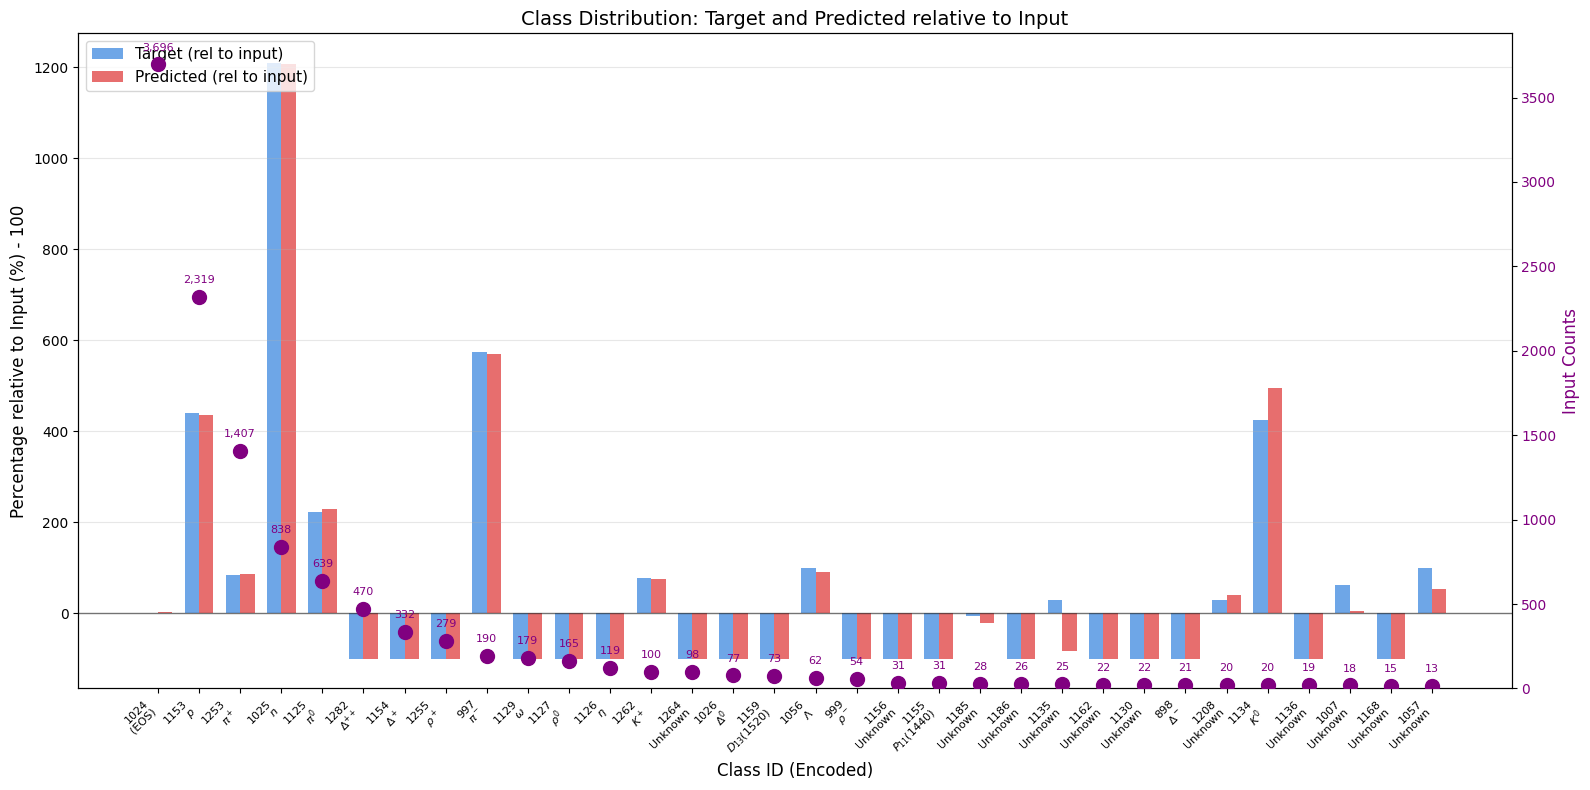


  Total input particles: 11,467
  Total target particles: 33,668
  Total predicted particles: 33,668
  Classes shown: 32 (out of 52 total)


In [79]:
from gibuu_transformer.data_processing import decode_id
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Dictionary mapping encoded IDs to particle names (LaTeX format)
PARTICLE_NAME_DICT = {
    1153: r"$p$",           # proton
    1025: r"$n$",           # neutron
    1253: r"$\pi^+$",       # pi+
    1125: r"$\pi^0$",       # pi0
    997: r"$\pi^-$",        # pi-
    1282: r"$\Delta^{++}$", # Delta++
    1154: r"$\Delta^+$",    # Delta+
    1026: r"$\Delta^0$",    # Delta0
    898: r"$\Delta^-$",     # Delta-
    1126: r"$\eta$",        # η (102, 0)
    1129: r"$\omega$",      # ω (105, 0)
    1255: r"$\rho^+$",      # ρ^+ (103, 1)
    1262: r"$K^+$",         # K^+ (110, 1)
    1127: r"$\rho^0$",      # ρ^0 (103, 0)
    1056: r"$\Lambda$",     # Λ (32, 0)
    999: r"$\rho^-$",       # ρ^- (103, -1)
    1134: r"$K^0$",         # K^0 (110, 0)
    1155: r"$P_{11}(1440)$", # P11(1440) (3, 1)
    1159: r"$D_{13}(1520)$", # D13(1520) (7, 1)
    1027: r"$P_{11}(1440)$", # P11(1440) (3, 0)
}


# ========== 1. CLASS DISTRIBUTIONS: Target and Predicted relative to Input ==========
print(f"{'='*80}")
print("1. CLASS DISTRIBUTIONS: Target and Predicted relative to Input")
print(f"{'='*80}")

# Get input types from test batches
all_input_types = []
all_input_masks = []

model_loaded.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        input_ids = batch['input_encoded_ids'].cpu()
        input_mask = ~batch['input_padding_mask'].cpu()
        all_input_types.append(input_ids)
        all_input_masks.append(input_mask)

# Concatenate and flatten
all_input_types_flat = torch.cat([t[m] for t, m in zip(all_input_types, all_input_masks)], dim=0).numpy()
all_target_types_flat = all_true_types[all_masks].cpu().numpy().flatten()
all_predicted_types_flat = all_predicted_types[all_masks].cpu().numpy().flatten()

# Get unique classes from all three
all_classes = np.unique(np.concatenate([all_input_types_flat, all_target_types_flat, all_predicted_types_flat]))

# Count occurrences
input_counts = np.array([np.sum(all_input_types_flat == c) for c in all_classes])
target_counts = np.array([np.sum(all_target_types_flat == c) for c in all_classes])
predicted_counts = np.array([np.sum(all_predicted_types_flat == c) for c in all_classes])

# Calculate target and predicted as percentages relative to input counts for each class
target_percentages_rel = np.zeros_like(target_counts, dtype=float)
predicted_percentages_rel = np.zeros_like(predicted_counts, dtype=float)

for i, input_count in enumerate(input_counts):
    if input_count > 0:
        target_percentages_rel[i] = (target_counts[i] / input_count) * 100
        predicted_percentages_rel[i] = (predicted_counts[i] / input_count) * 100

# Filter for classes with significant input counts (e.g., >0.1% of total input)
input_total = input_counts.sum()
min_percentage = 0.1
significant_mask = (input_counts / input_total * 100) > min_percentage if input_total > 0 else input_counts > 0
filtered_classes = all_classes[significant_mask]
filtered_target_pct = target_percentages_rel[significant_mask]
filtered_predicted_pct = predicted_percentages_rel[significant_mask]
filtered_input_counts = input_counts[significant_mask]

# Sort by descending input counts
sort_indices = np.argsort(filtered_input_counts)[::-1]
filtered_classes = filtered_classes[sort_indices]
filtered_target_pct = filtered_target_pct[sort_indices]
filtered_predicted_pct = filtered_predicted_pct[sort_indices]
filtered_input_counts = filtered_input_counts[sort_indices]

# Create labels
def create_simple_class_label(encoded_id):
    """Create label with encoded ID and particle name only."""
    encoded_id_int = int(encoded_id)
    
    if encoded_id_int == EOS_STEP_TOKEN:
        return f"{encoded_id_int}\n(EOS)"
    elif encoded_id_int == PAD_TOKEN:
        return f"{encoded_id_int}\n(PAD)"
    elif encoded_id_int == START_TOKEN:
        return f"{encoded_id_int}\n(START)"
    else:
        particle_name = PARTICLE_NAME_DICT.get(encoded_id_int, "Unknown")
        return f"{encoded_id_int}\n{particle_name}"

class_labels = [create_simple_class_label(c) for c in filtered_classes]

# Plot
fig, ax1 = plt.subplots(figsize=(16, 8))

x_pos = np.arange(len(filtered_classes))
width = 0.35

# Subtract 100 from percentages (so 100% becomes 0%, 109% becomes 9%, etc.)
filtered_target_pct_centered = filtered_target_pct - 100
filtered_predicted_pct_centered = filtered_predicted_pct - 100

# Left axis: percentages relative to input (centered at 0)
bars2 = ax1.bar(x_pos - width/2, filtered_target_pct_centered, width, label='Target (rel to input)', alpha=0.8, color='#4A90E2')
bars3 = ax1.bar(x_pos + width/2, filtered_predicted_pct_centered, width, label='Predicted (rel to input)', alpha=0.8, color='#E24A4A')

# Add horizontal line at 0
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax1.set_xlabel('Class ID (Encoded)', fontsize=12)
ax1.set_ylabel('Percentage relative to Input (%) - 100', fontsize=12, color='black')
ax1.set_title('Class Distribution: Target and Predicted relative to Input', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=8)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Right axis: input counts
ax2 = ax1.twinx()
markers = ax2.scatter(x_pos, filtered_input_counts, color='purple', s=100, marker='o', zorder=5, label='Input Counts')
ax2.set_ylabel('Input Counts', fontsize=12, color='purple')
ax2.set_ylim(0, None)
ax2.tick_params(axis='y', labelcolor='purple')

# Add count annotations
for i, (x, count) in enumerate(zip(x_pos, filtered_input_counts)):
    if count > 0:
        ax2.annotate(f'{count:,}', (x, count), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=8, color='purple')

plt.tight_layout()
plt.show()

print(f"\n  Total input particles: {input_total:,}")
print(f"  Total target particles: {target_counts.sum():,}")
print(f"  Total predicted particles: {predicted_counts.sum():,}")
print(f"  Classes shown: {len(filtered_classes)} (out of {len(all_classes)} total)")



2. FEATURE DISTRIBUTIONS: Target vs Predicted
================================================================================ (all particles)


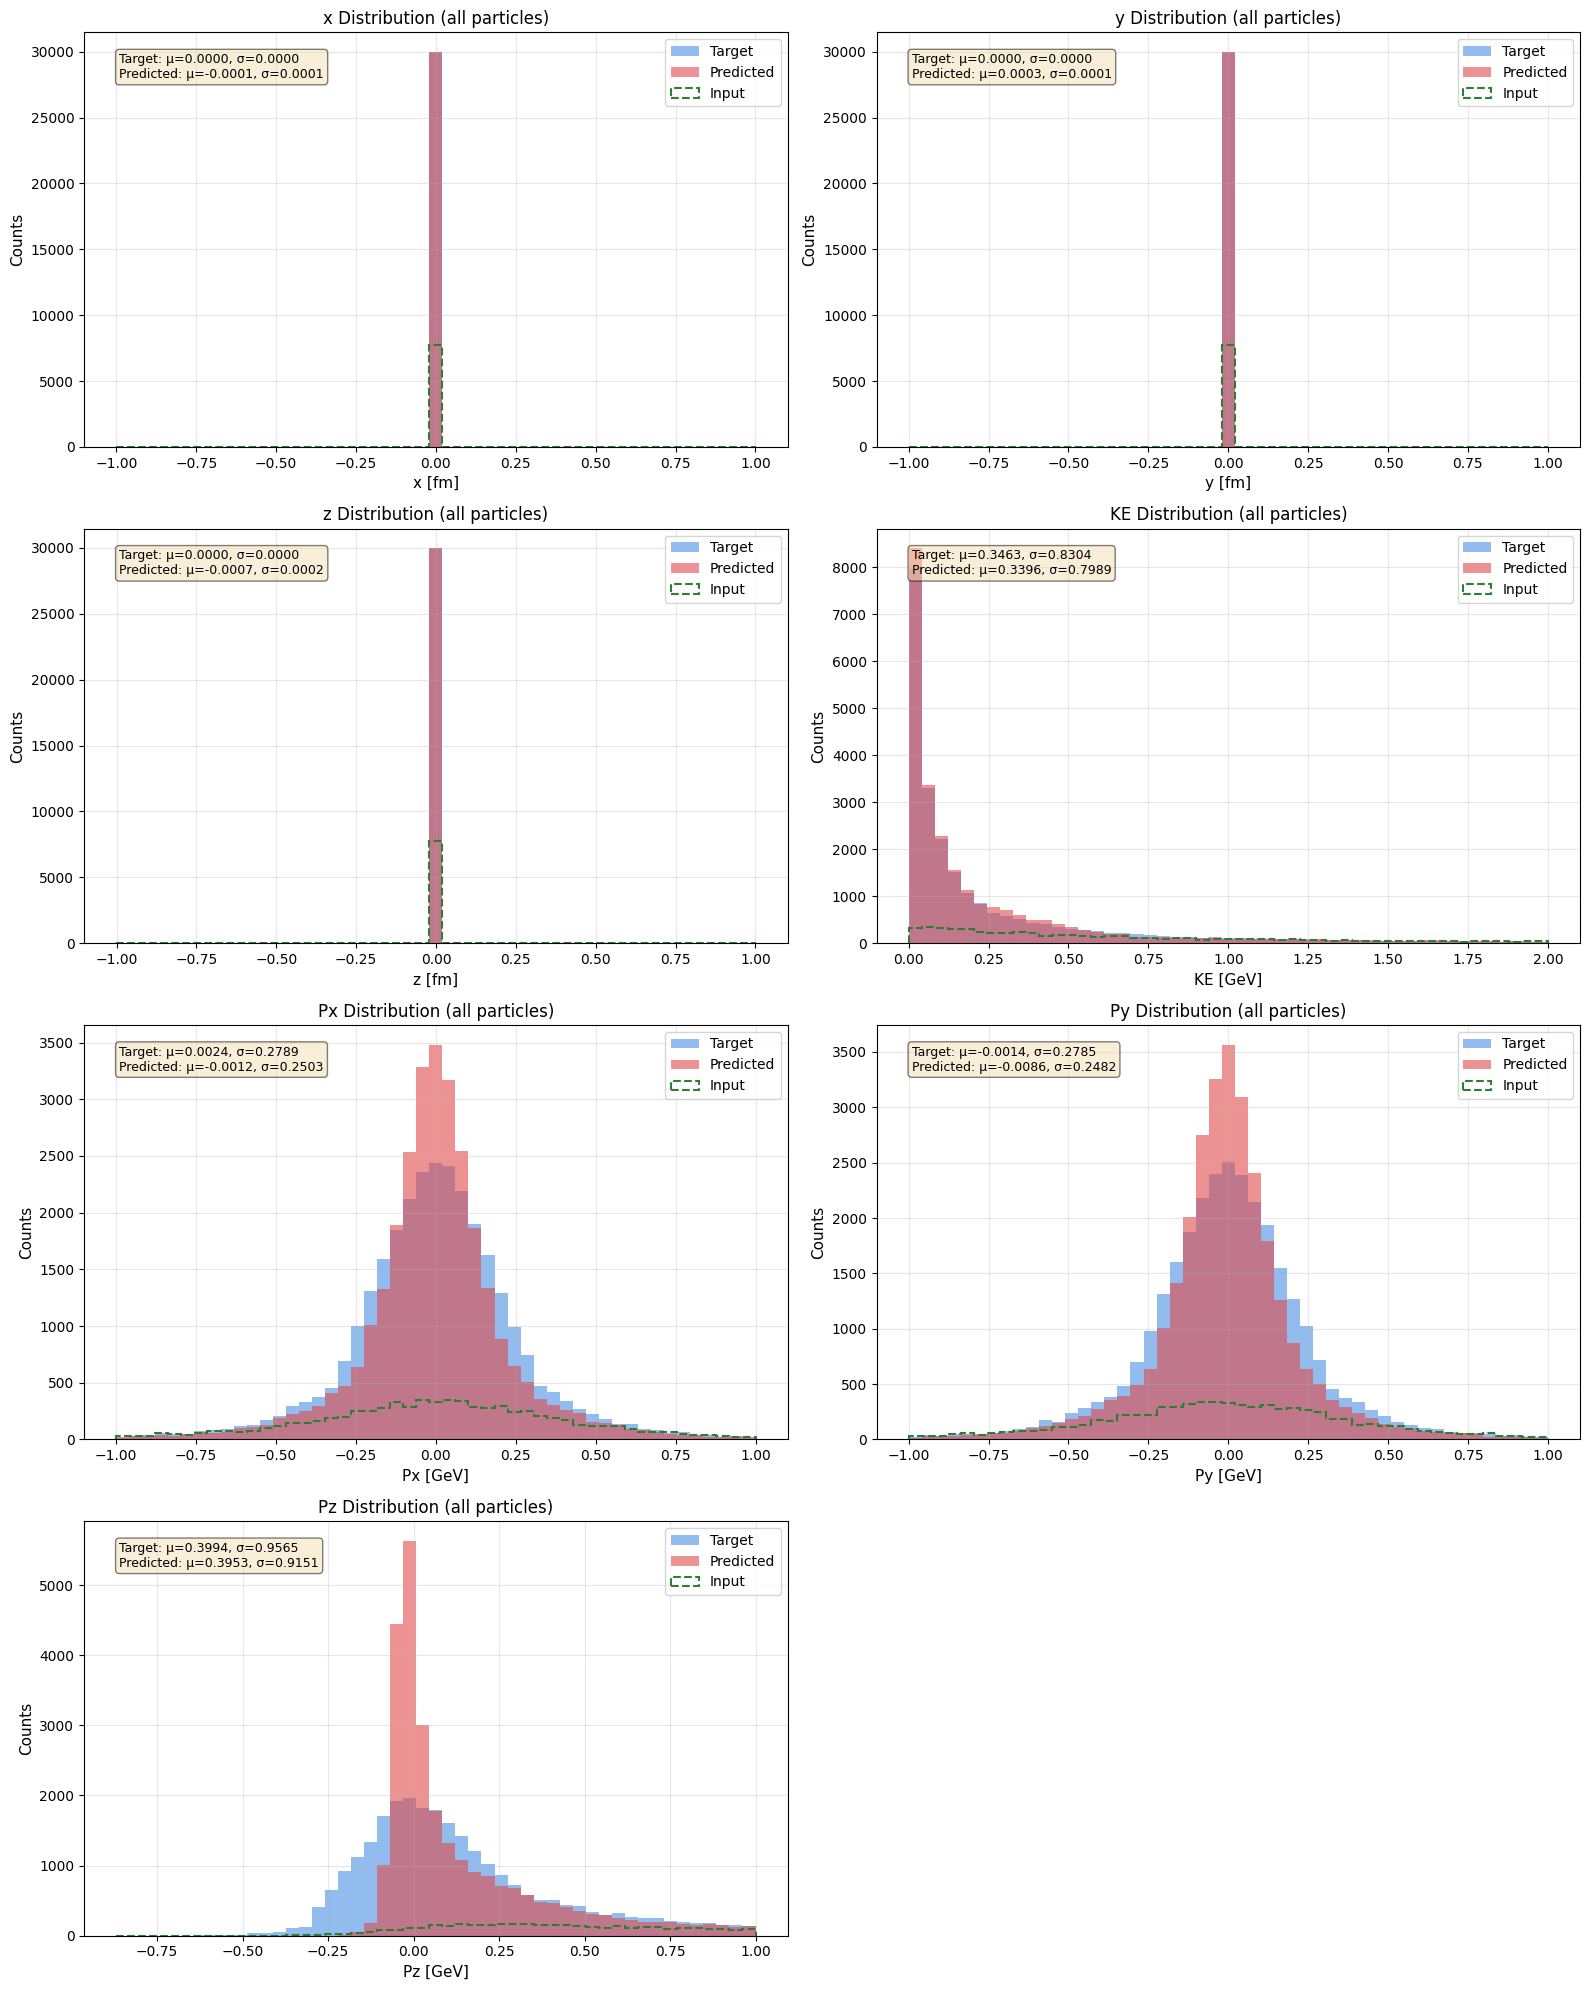

In [80]:
# Set to None to show all particles, or provide a single ID or list of IDs
FILTER_BY_IDS = None  # Example: 1153 for proton, or [1153, 1025] for proton and neutron

# ========== 2. FEATURE DISTRIBUTIONS: Target vs Predicted (with FILTER_BY_IDS) ==========
print(f"\n{'='*80}")
print(f"2. FEATURE DISTRIBUTIONS: Target vs Predicted")
if FILTER_BY_IDS is not None:
    filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
    filter_str = f" (filtered: IDs={filter_ids})"
    print(f"{'='*80}{filter_str}")
else:
    filter_str = " (all particles)"
    print(f"{'='*80}{filter_str}")

# Feature names and indices
feature_info = [
    (0, 'x', 'x [fm]'),
    (1, 'y', 'y [fm]'),
    (2, 'z', 'z [fm]'),
    (3, 'KE', 'KE [GeV]'),
    (4, 'Px', 'Px [GeV]'),
    (5, 'Py', 'Py [GeV]'),
    (6, 'Pz', 'Pz [GeV]'),
]

# Get input features and types from test batches
all_input_feats = []
all_input_types_list = []
all_input_masks_list = []

model_loaded.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        input_feats = batch['input_particle_feats'].cpu()
        input_ids = batch['input_encoded_ids'].cpu()
        input_mask = ~batch['input_padding_mask'].cpu()
        all_input_feats.append(input_feats)
        all_input_types_list.append(input_ids)
        all_input_masks_list.append(input_mask)

# Concatenate and flatten input features
all_input_feats_flat = torch.cat([t[m] for t, m in zip(all_input_feats, all_input_masks_list)], dim=0)  # (num_input_particles, 7)
# Denormalize input features
feats_mean_tensor = torch.tensor(FEATS_MEAN, dtype=torch.float32)
feats_sigma_tensor = torch.tensor(FEATS_SIGMA, dtype=torch.float32)
input_feats_denorm = all_input_feats_flat * feats_sigma_tensor.unsqueeze(0) + feats_mean_tensor.unsqueeze(0)

# Concatenate and flatten input types
all_input_types_flat = torch.cat([t[m] for t, m in zip(all_input_types_list, all_input_masks_list)], dim=0).numpy()

# Flatten all data
pred_ids_flat = all_predicted_types.flatten()
true_ids_flat = all_true_types.flatten()
valid_mask_flat = all_masks.flatten()

# Convert to numpy
if isinstance(pred_ids_flat, torch.Tensor):
    pred_ids_flat = pred_ids_flat.cpu().numpy()
if isinstance(true_ids_flat, torch.Tensor):
    true_ids_flat = true_ids_flat.cpu().numpy()
if isinstance(valid_mask_flat, torch.Tensor):
    valid_mask_flat = valid_mask_flat.cpu().numpy()

# Create mask for target/predicted
if FILTER_BY_IDS is not None:
    filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
    feature_mask = valid_mask_flat & (true_ids_flat != PAD_TOKEN)
    feature_mask = feature_mask & np.isin(true_ids_flat, filter_ids)
else:
    feature_mask = valid_mask_flat & (true_ids_flat != PAD_TOKEN) & (true_ids_flat != EOS_STEP_TOKEN)

# Create mask for input (same filtering logic)
if FILTER_BY_IDS is not None:
    filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
    input_feature_mask = (all_input_types_flat != PAD_TOKEN) & np.isin(all_input_types_flat, filter_ids)
else:
    input_feature_mask = (all_input_types_flat != PAD_TOKEN) & (all_input_types_flat != EOS_STEP_TOKEN)

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, (feat_idx, feat_short, feat_name) in enumerate(feature_info):
    ax = axes[idx]
    
    # Get feature values
    pred_feat_flat = predicted_feats_denorm[..., feat_idx].flatten()
    true_feat_flat = true_feats_denorm[..., feat_idx].flatten()
    
    # Convert to numpy if needed
    if isinstance(pred_feat_flat, torch.Tensor):
        pred_feat_flat = pred_feat_flat.cpu().numpy()
    if isinstance(true_feat_flat, torch.Tensor):
        true_feat_flat = true_feat_flat.cpu().numpy()
    
    # Apply mask
    if len(pred_feat_flat) != len(feature_mask) or len(true_feat_flat) != len(feature_mask):
        min_len = min(len(pred_feat_flat), len(true_feat_flat), len(feature_mask))
        pred_feat_flat = pred_feat_flat[:min_len]
        true_feat_flat = true_feat_flat[:min_len]
        feature_mask_local = feature_mask[:min_len]
    else:
        feature_mask_local = feature_mask
    
    pred_feat_masked = pred_feat_flat[feature_mask_local]
    true_feat_masked = true_feat_flat[feature_mask_local]
    
    # Determine bins
    combined_data = np.concatenate([true_feat_masked, pred_feat_masked])
    if len(combined_data) > 0:
        data_min = np.min(combined_data)
        data_max = np.max(combined_data)
        
        if feat_short in ['x', 'y', 'z']:
            bin_min = max(-20, data_min - 1)
            bin_max = min(20, data_max + 1)
            n_bins = 50
        elif feat_short == 'KE':
            bin_min = 0
            # Limit KE range to reasonable values (e.g., 0-2 GeV)
            bin_max = min(2.0, max(0.5, data_max + 0.1))
            n_bins = 50
        else:  # Px, Py, Pz
            bin_min = max(-1, data_min - 0.1)
            bin_max = min(1, data_max + 0.1)
            n_bins = 50
        
        bins = np.linspace(bin_min, bin_max, n_bins)
    else:
        if feat_short in ['x', 'y', 'z']:
            bins = np.linspace(-20, 20, 50)
        elif feat_short == 'KE':
            bins = np.linspace(0, 2, 50)  # Limit KE range to 0-2 GeV
        else:
            bins = np.linspace(-1, 1, 50)
    
    # Get input feature values
    input_feat_flat = input_feats_denorm[:, feat_idx].cpu().numpy() if isinstance(input_feats_denorm, torch.Tensor) else input_feats_denorm[:, feat_idx]
    input_feat_masked = input_feat_flat[input_feature_mask]
    
    # Plot histograms
    ax.hist(true_feat_masked, bins=bins, alpha=0.6, label='Target', color='#4A90E2', edgecolor='none')
    ax.hist(pred_feat_masked, bins=bins, alpha=0.6, label='Predicted', color='#E24A4A', edgecolor='none')
    # Overlay input distribution as unfilled histogram with dim green line
    ax.hist(input_feat_masked, bins=bins, alpha=1, label='Input', color='#2E7D32', edgecolor='#2E7D32', linewidth=1.5, linestyle='--', histtype='step')
    
    ax.set_xlabel(feat_name, fontsize=11)
    ax.set_ylabel('Counts', fontsize=11)
    ax.set_title(f'{feat_short} Distribution{filter_str}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    # Add statistics
    true_mean = np.mean(true_feat_masked)
    true_std = np.std(true_feat_masked)
    pred_mean = np.mean(pred_feat_masked)
    pred_std = np.std(pred_feat_masked)
    
    stats_text = f'Target: μ={true_mean:.4f}, σ={true_std:.4f}\n'
    stats_text += f'Predicted: μ={pred_mean:.4f}, σ={pred_std:.4f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide the last subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()



3. CLASS CONFUSION MATRIX


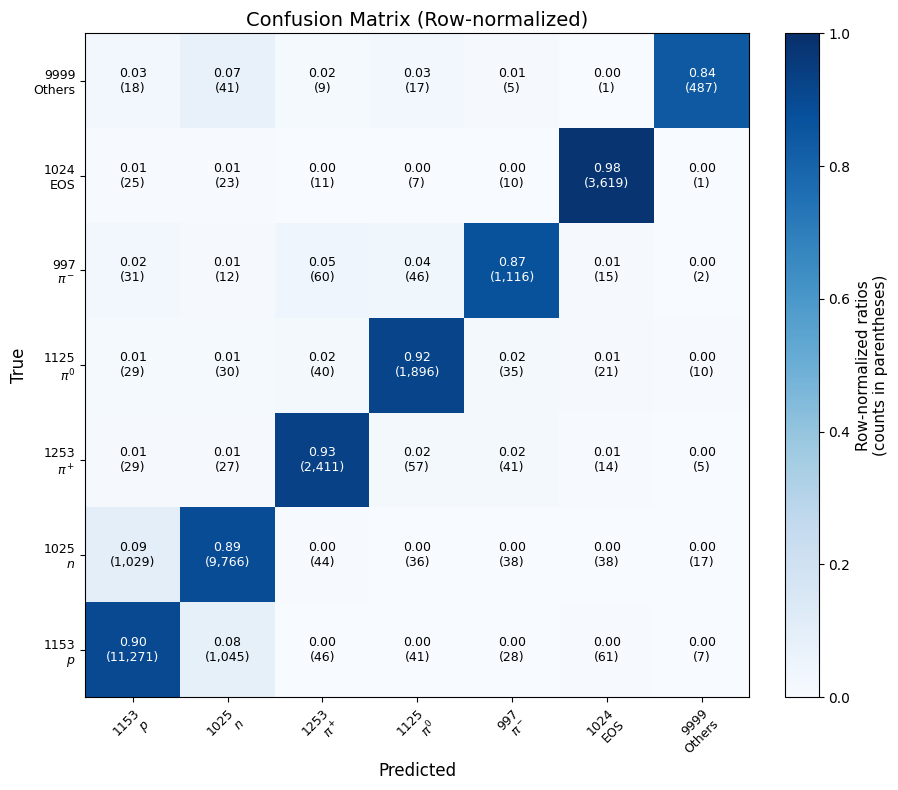

  Main classes: ['$p$', '$n$', '$\\pi^+$', '$\\pi^0$', '$\\pi^-$', 'Class 1024']
  Total predictions: 33,668


In [81]:
# ========== 3. CLASS CONFUSION MATRIX ==========
print(f"\n{'='*80}")
print("3. CLASS CONFUSION MATRIX")
print(f"{'='*80}")

# Flatten targets and predictions (excluding PAD tokens)
flat_targets = all_true_types[all_masks].cpu().numpy().flatten()
flat_predictions = all_predicted_types[all_masks].cpu().numpy().flatten()

# Count occurrences
unique, counts = np.unique(flat_targets, return_counts=True)
total = counts.sum()
percentages = counts / total

# Filter for classes exceeding 1%
main_encoded_ids = [1153, 1025, 1253, 1125, 997]  # p, n, pi+, pi0, pi-
main_names = [PARTICLE_NAME_DICT.get(eid, f"Class {eid}") for eid in main_encoded_ids]

# Add EOS token
main_encoded_ids.append(EOS_STEP_TOKEN)
main_names.append("EOS")

# If main classes are not in the data, use top classes from distribution
threshold = 0.01
significant_classes = unique[percentages > threshold]
for eid in main_encoded_ids:
    if eid not in significant_classes and eid in unique:
        significant_classes = np.append(significant_classes, eid)

# Use intersection of main classes and significant classes
main_encoded_ids = [eid for eid in main_encoded_ids if eid in significant_classes]
main_names = [PARTICLE_NAME_DICT.get(eid, f"Class {eid}") for eid in main_encoded_ids]
if EOS_STEP_TOKEN in significant_classes and EOS_STEP_TOKEN not in main_encoded_ids:
    main_encoded_ids.append(EOS_STEP_TOKEN)
    main_names.append("EOS")

others_label = 9999

# Map all other classes to "Others"
y_true_mapped = flat_targets.copy()
y_pred_mapped = flat_predictions.copy()

for i, true_id in enumerate(flat_targets):
    if true_id not in main_encoded_ids:
        y_true_mapped[i] = others_label
    if flat_predictions[i] not in main_encoded_ids:
        y_pred_mapped[i] = others_label

# Prepare labels
labels = main_encoded_ids + [others_label]
label_names = main_names + ['Others']

# Compute confusion matrix
cm_counts = confusion_matrix(y_true_mapped, y_pred_mapped, labels=labels)

# Normalize along each true axis (row)
cm_ratios = cm_counts.astype(float)
row_sums = cm_ratios.sum(axis=1, keepdims=True)
cm_ratios = np.divide(cm_ratios, row_sums, where=row_sums != 0)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_ratios, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

# Add text annotations
thresh = cm_ratios.max() / 2.
for i in range(len(labels)):
    for j in range(len(labels)):
        ratio = cm_ratios[i, j]
        count = cm_counts[i, j]
        text = ax.text(j, i, f'{ratio:.2f}\n({count:,})',
                      ha="center", va="center",
                      color="white" if ratio > thresh else "black", fontsize=9)

# Create labels for confusion matrix
def create_confusion_label(encoded_id_int, name):
    """Create label for confusion matrix."""
    if encoded_id_int == EOS_STEP_TOKEN:
        return f"{encoded_id_int}\nEOS"
    elif encoded_id_int == others_label:
        return f"{encoded_id_int}\nOthers"
    else:
        particle_name = PARTICLE_NAME_DICT.get(encoded_id_int, name)
        return f"{encoded_id_int}\n{particle_name}"

confusion_labels = [create_confusion_label(lid, name) for lid, name in zip(labels, label_names)]

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(confusion_labels, fontsize=9)
ax.set_yticklabels(confusion_labels, fontsize=9)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title("Confusion Matrix (Row-normalized)", fontsize=14)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.invert_yaxis()

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Row-normalized ratios\n(counts in parentheses)", fontsize=11)

plt.tight_layout()
plt.show()

print(f"  Main classes: {label_names[:-1]}")
print(f"  Total predictions: {len(flat_targets):,}")



4. FEATURE 2D COMPARISON PLOTS (Predicted vs True, all particles)
================================================================================ (all particles)

Note: Only showing particles with matched IDs (predicted type == true type)
      Excluding EOS and PAD tokens



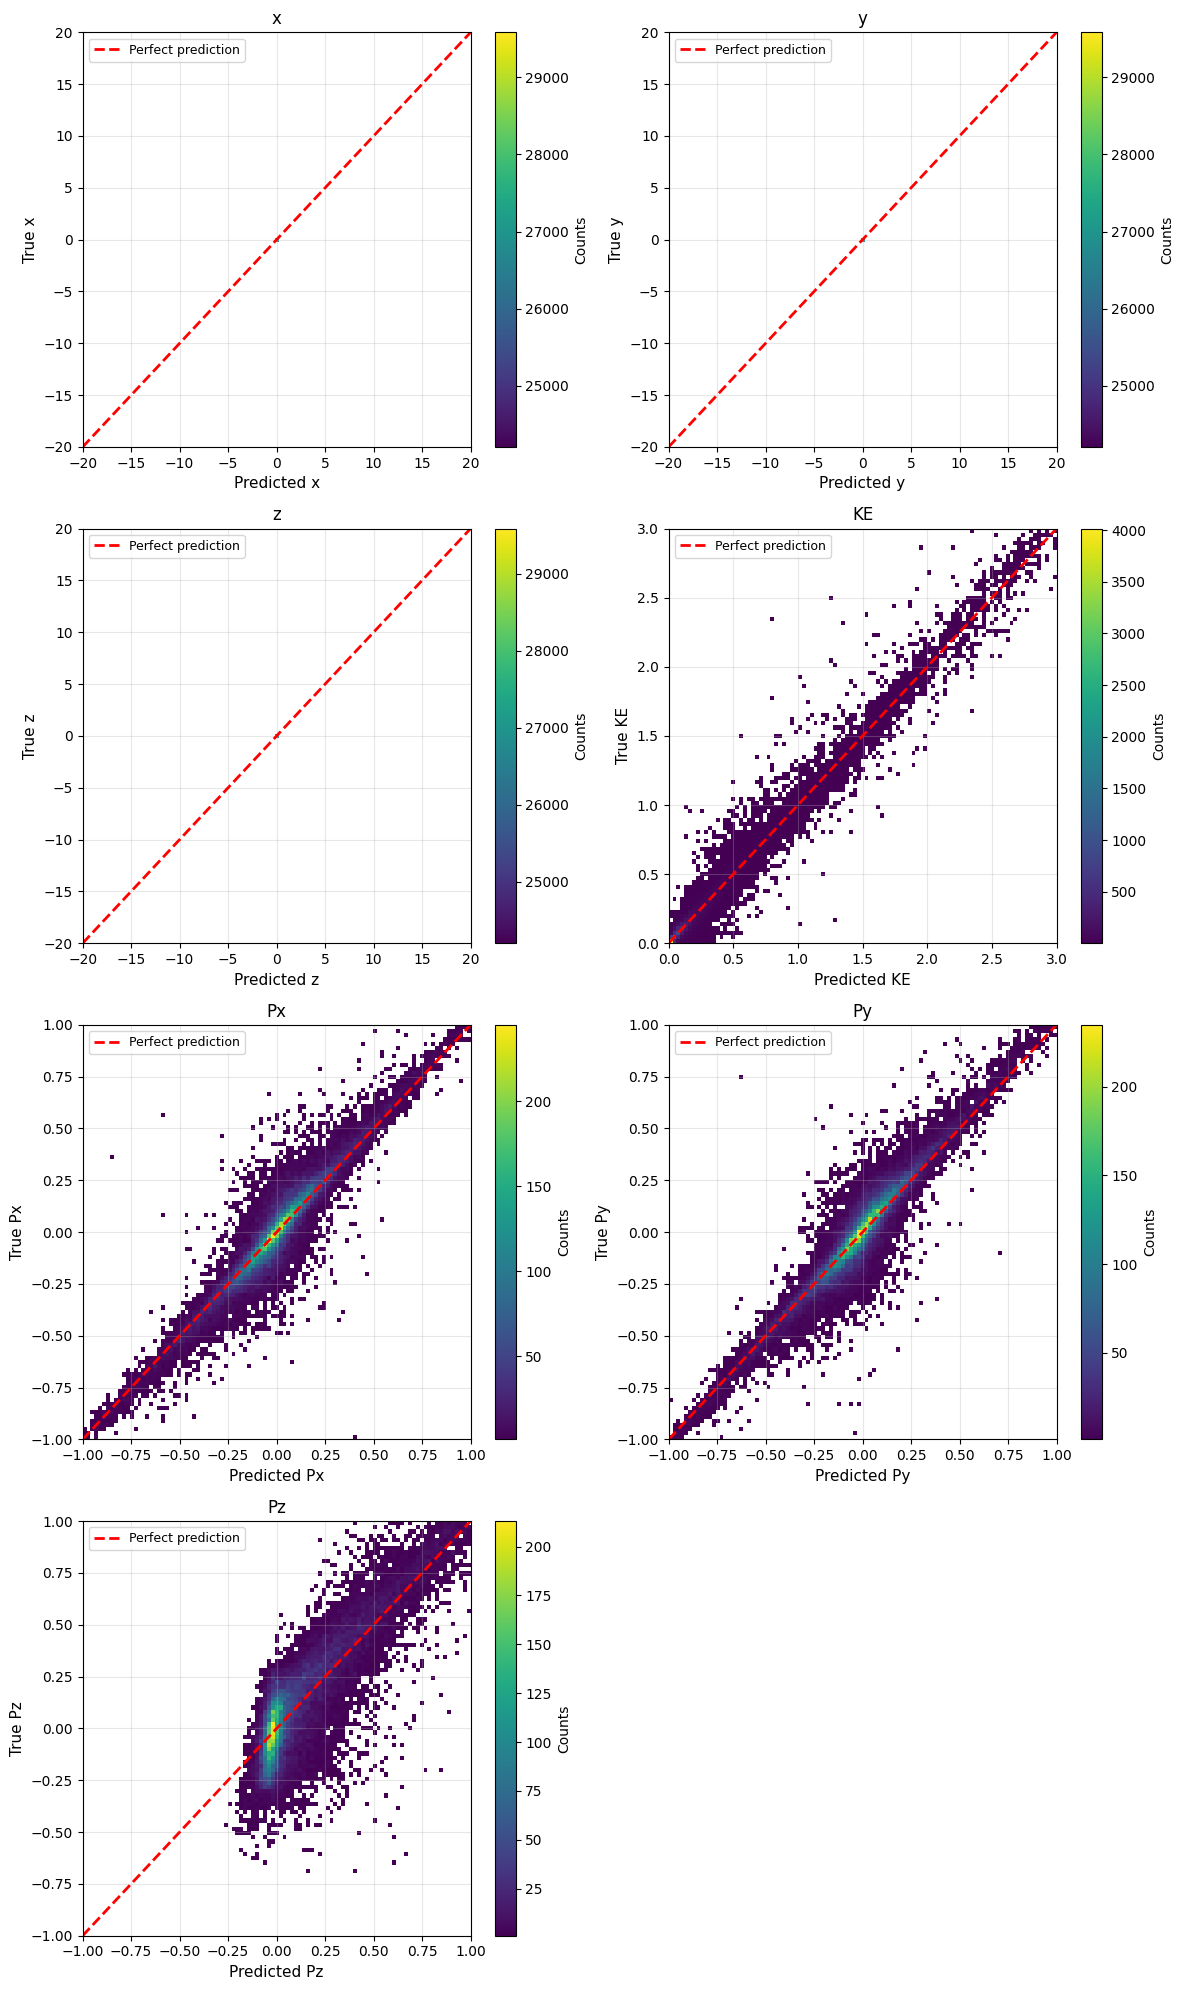


FEATURE STATISTICS (matched IDs only)
Feature  MAE          RMSE         MedAE        N           
--------------------------------------------------------------------------------
x        0.000084     0.000112     0.000061     26,895      
y        0.000289     0.000301     0.000290     26,895      
z        0.000701     0.000725     0.000721     26,895      
KE       0.042974     0.088021     0.017601     26,895      
Px       0.057743     0.088246     0.036557     26,895      
Py       0.058478     0.087960     0.038156     26,895      
Pz       0.112333     0.154462     0.087279     26,895      


In [82]:
# Configuration: filter by embedded ID(s) if desired
# Set to None to show all particles, or provide a single ID or list of IDs
FILTER_BY_IDS = None  # Example: 1153 for proton, or [1153, 1025] for proton and neutron

# ========== 4. FEATURE 2D COMPARISON PLOTS (for all particles) ==========
print(f"\n{'='*80}")
print("4. FEATURE 2D COMPARISON PLOTS (Predicted vs True, all particles)")
if FILTER_BY_IDS is not None:
    filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
    filter_str = f" (filtered: IDs={filter_ids})"
    print(f"{'='*80}{filter_str}")
else:
    filter_str = " (all particles)"
    print(f"{'='*80}{filter_str}")
print("\nNote: Only showing particles with matched IDs (predicted type == true type)")
print("      Excluding EOS and PAD tokens\n")

def plot_2d_feature_distribution_subplot(
    ax, all_feats_pred, all_feats_target, all_preds, all_targets, all_masks,
    feature_index, feature_name, matched=True, particle_id=None, bins=None
):
    """Draws a 2D histogram of a feature: predicted vs. true on a given axis."""
    # Flatten everything
    pred_ids = all_preds.flatten()
    true_ids = all_targets.flatten()
    pred_feat = all_feats_pred[..., feature_index].flatten()
    true_feat = all_feats_target[..., feature_index].flatten()
    valid_mask = all_masks.flatten()
    
    # Mask for non-particle tokens
    mask = valid_mask & (true_ids != PAD_TOKEN) & (true_ids != EOS_STEP_TOKEN)
    if matched:
        mask = mask & (pred_ids == true_ids)
    if particle_id is not None:
        if type(particle_id) is int:
            particle_id = [particle_id]
        mask = mask & np.isin(true_ids, particle_id)
    
    # Apply mask
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    x = pred_feat[mask].cpu().numpy() if isinstance(pred_feat, torch.Tensor) else pred_feat[mask]
    y = true_feat[mask].cpu().numpy() if isinstance(true_feat, torch.Tensor) else true_feat[mask]

    # Set bins
    if bins is None:
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        bins = np.linspace(min_val, max_val, 101)
    xmin = bins[0]
    xmax = bins[-1]

    # Plot 2D histogram
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad('white')
    
    h = ax.hist2d(x, y, bins=bins, cmap=cmap, cmin=1)
    ax.plot([xmin, xmax], [xmin, xmax], "r--", linewidth=2, label="Perfect prediction")
    ax.set_xlabel(f"Predicted {feature_name}", fontsize=11)
    ax.set_ylabel(f"True {feature_name}", fontsize=11)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_title(feature_name, fontsize=12)
    plt.colorbar(h[3], ax=ax, label="Counts")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Return statistics
    errors = np.abs(x - y)
    return {
        'mae': errors.mean(),
        'rmse': np.sqrt(np.mean((x - y)**2)),
        'medae': np.median(errors),
        'n_points': len(x)
    }

# Feature info
feature_info_2d = [
    (0, 'x', 'x [fm]'),
    (1, 'y', 'y [fm]'),
    (2, 'z', 'z [fm]'),
    (3, 'KE', 'KE [GeV]'),
    (4, 'Px', 'Px [GeV]'),
    (5, 'Py', 'Py [GeV]'),
    (6, 'Pz', 'Pz [GeV]'),
]

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
axes = axes.flatten()

stats_dict = {}
for idx, (feat_idx, feat_short, feat_name) in enumerate(feature_info_2d):
    # Determine bins
    if feat_short in ['x', 'y', 'z']:
        bins = np.linspace(-20, 20, 100)
    elif feat_short == 'KE':
        bins = np.linspace(0, 3, 100)
    else:  # Px, Py, Pz
        bins = np.linspace(-1, 1, 100)
    
    # Apply FILTER_BY_IDS if specified
    particle_id_filter = None
    if FILTER_BY_IDS is not None:
        filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
        particle_id_filter = filter_ids
    
    stats = plot_2d_feature_distribution_subplot(
        axes[idx], predicted_feats_denorm, true_feats_denorm,
        all_predicted_types, all_true_types, all_masks,
        feature_index=feat_idx, 
        feature_name=feat_short,
        matched=True,
        particle_id=particle_id_filter,
        bins=bins
    )
    stats_dict[feat_short] = stats

# Hide the last subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("FEATURE STATISTICS (matched IDs only)")
print(f"{'='*80}")
print(f"{'Feature':<8} {'MAE':<12} {'RMSE':<12} {'MedAE':<12} {'N':<12}")
print(f"{'-'*80}")
for feat_short in ['x', 'y', 'z', 'KE', 'Px', 'Py', 'Pz']:
    stats = stats_dict[feat_short]
    print(f"{feat_short:<8} {stats['mae']:<12.6f} {stats['rmse']:<12.6f} {stats['medae']:<12.6f} {stats['n_points']:<12,}")



5. MULTIPLICITY DISTRIBUTIONS: Target vs Predicted
================================================================================ (filtered: $p$, $n$, $\pi^-$)


/tmp/ipykernel_38276/2579876172.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  event_input_mask = event_input_mask & np.isin(input_ids[i].cpu().numpy(), filter_ids)
/tmp/ipykernel_38276/2579876172.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  event_mask = event_mask & np.isin(all_true_types[i].cpu().numpy(), filter_ids)
/tmp/ipykernel_38276/2579876172.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_event_mask = pred_event_mask & np.isin(all_predicted_types[i].cpu().numpy(), filter_ids)


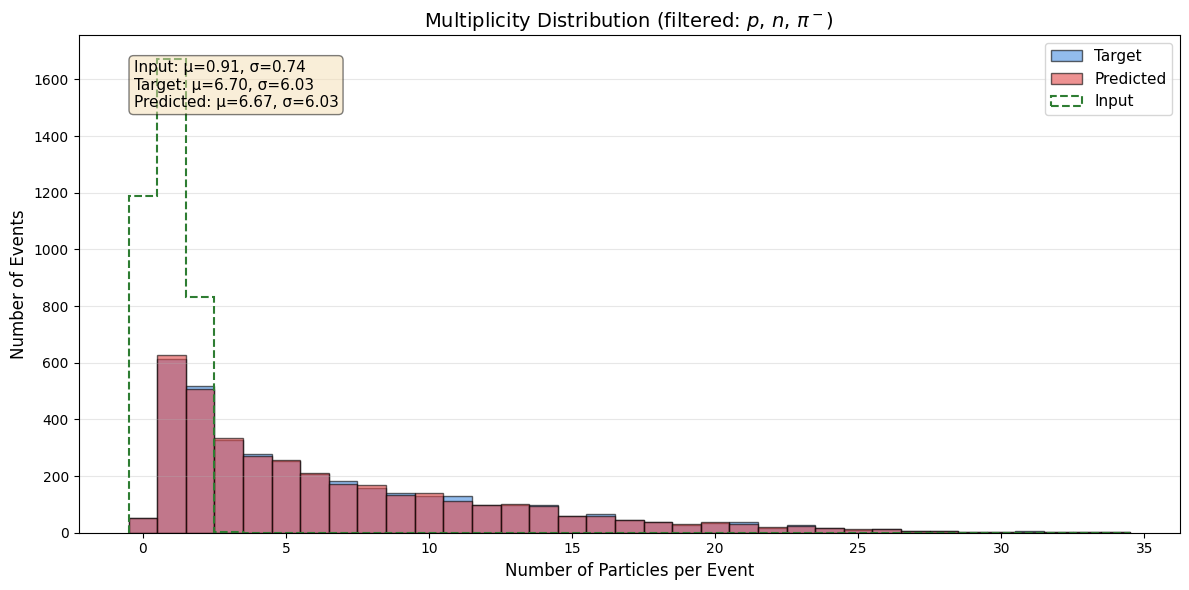


  Input multiplicity - mean: 0.91, std: 0.74
  Target multiplicity - mean: 6.70, std: 6.03
  Predicted multiplicity - mean: 6.67, std: 6.03
  Total events: 3,696

✓ All validation plots completed


In [83]:
# Set to None to show all particles, or provide a single ID or list of IDs
FILTER_BY_IDS = [1153, 1025]  # Example: 1153 for proton, or [1153, 1025] for proton and neutron

# ========== 5. MULTIPLICITY DISTRIBUTIONS: Target vs Predicted (with FILTER_BY_IDS) ==========
print(f"\n{'='*80}")
print("5. MULTIPLICITY DISTRIBUTIONS: Target vs Predicted")
if FILTER_BY_IDS is not None:
    filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
    # Get particle names in LaTeX format and join them with commas
    filter_names = [PARTICLE_NAME_DICT.get(fid, f"ID {fid}") for fid in filter_ids]
    # Join LaTeX names with commas (no brackets/quotes in the string)
    filter_names_str = ", ".join(filter_names)
    filter_str = f" (filtered: {filter_names_str})"
    print(f"{'='*80}{filter_str}")
else:
    filter_str = " (all particles)"
    print(f"{'='*80}{filter_str}")

# Get input multiplicities from test batches
all_input_multiplicities = []

model_loaded.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        input_ids = batch['input_encoded_ids'].cpu()
        input_mask = ~batch['input_padding_mask'].cpu()
        
        # Count particles per event in input
        for i in range(input_ids.shape[0]):
            event_input_mask = input_mask[i] & (input_ids[i] != PAD_TOKEN) & (input_ids[i] != EOS_STEP_TOKEN)
            
            if FILTER_BY_IDS is not None:
                filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
                event_input_mask = event_input_mask & np.isin(input_ids[i].cpu().numpy(), filter_ids)
            
            input_count = event_input_mask.sum().item()
            all_input_multiplicities.append(input_count)

# Count particles per event (excluding PAD and EOS)
batch_size = all_true_types.shape[0]
target_multiplicities = []
predicted_multiplicities = []

for i in range(batch_size):
    # Get valid particles for this event
    event_mask = all_masks[i] & (all_true_types[i] != PAD_TOKEN) & (all_true_types[i] != EOS_STEP_TOKEN)
    
    if FILTER_BY_IDS is not None:
        filter_ids = [int(FILTER_BY_IDS)] if isinstance(FILTER_BY_IDS, (int, np.integer)) else [int(fid) for fid in FILTER_BY_IDS]
        event_mask = event_mask & np.isin(all_true_types[i].cpu().numpy(), filter_ids)
    
    # Count particles
    target_count = event_mask.sum().item()
    target_multiplicities.append(target_count)
    
    # For predicted, count where predicted ID matches filter (if filtering)
    if FILTER_BY_IDS is not None:
        pred_event_mask = all_masks[i] & (all_predicted_types[i] != PAD_TOKEN) & (all_predicted_types[i] != EOS_STEP_TOKEN)
        pred_event_mask = pred_event_mask & np.isin(all_predicted_types[i].cpu().numpy(), filter_ids)
        predicted_count = pred_event_mask.sum().item()
    else:
        pred_event_mask = all_masks[i] & (all_predicted_types[i] != PAD_TOKEN) & (all_predicted_types[i] != EOS_STEP_TOKEN)
        predicted_count = pred_event_mask.sum().item()
    
    predicted_multiplicities.append(predicted_count)

input_multiplicities = np.array(all_input_multiplicities)
target_multiplicities = np.array(target_multiplicities)
predicted_multiplicities = np.array(predicted_multiplicities)

# Plot histogram
fig, ax = plt.subplots(figsize=(12, 6))

max_mult = max(input_multiplicities.max(), target_multiplicities.max(), predicted_multiplicities.max())
bins = np.arange(0, max_mult + 2) - 0.5

ax.hist(target_multiplicities, bins=bins, alpha=0.6, label='Target', color='#4A90E2', edgecolor='black')
ax.hist(predicted_multiplicities, bins=bins, alpha=0.6, label='Predicted', color='#E24A4A', edgecolor='black')
ax.hist(input_multiplicities, bins=bins, alpha=1, label='Input', color='#2E7D32', edgecolor='#2E7D32', linewidth=1.5, linestyle='--', histtype='step')

ax.set_xlabel('Number of Particles per Event', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.set_title(f'Multiplicity Distribution{filter_str}', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

# Add statistics
input_mean = np.mean(input_multiplicities)
input_std = np.std(input_multiplicities)
target_mean = np.mean(target_multiplicities)
target_std = np.std(target_multiplicities)
pred_mean = np.mean(predicted_multiplicities)
pred_std = np.std(predicted_multiplicities)

stats_text = f'Input: μ={input_mean:.2f}, σ={input_std:.2f}\n'
stats_text += f'Target: μ={target_mean:.2f}, σ={target_std:.2f}\n'
stats_text += f'Predicted: μ={pred_mean:.2f}, σ={pred_std:.2f}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
        verticalalignment='top', fontsize=11, 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n  Input multiplicity - mean: {input_mean:.2f}, std: {input_std:.2f}")
print(f"  Target multiplicity - mean: {target_mean:.2f}, std: {target_std:.2f}")
print(f"  Predicted multiplicity - mean: {pred_mean:.2f}, std: {pred_std:.2f}")
print(f"  Total events: {batch_size:,}")

print(f"\n{'='*80}")
print("✓ All validation plots completed")
print(f"{'='*80}")
